In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:

PROJECT_DIR = Path(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric"
)

PREPARED_DIR = PROJECT_DIR / "prepared_data"

X_train = pd.read_csv(
    PREPARED_DIR / "X_train_processed.csv"
)

X_test = pd.read_csv(
    PREPARED_DIR / "X_test_processed.csv"
)

y_train = pd.read_csv(
    PREPARED_DIR / "y_train.csv"
)

y_test = pd.read_csv(
    PREPARED_DIR / "y_test.csv"
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("Training outcomes:", y_train.shape)
print("Test outcomes:", y_test.shape)

print("\nFeature columns:")
print(X_train.columns.tolist())

Training features: (1583, 12)
Test features: (397, 12)
Training outcomes: (1583, 2)
Test outcomes: (397, 2)

Feature columns:
['AGE_AT_DIAGNOSIS', 'TUMOR_SIZE', 'LYMPH_NODES_EXAMINED_POSITIVE', 'GRADE_1.0', 'GRADE_2.0', 'GRADE_3.0', 'ER_STATUS_Negative', 'ER_STATUS_Positive', 'PR_STATUS_Negative', 'PR_STATUS_Positive', 'HER2_STATUS_Negative', 'HER2_STATUS_Positive']


In [5]:

assert len(X_train) == len(y_train)

assert len(X_test) == len(y_test)

assert X_train.columns.equals(X_test.columns)

assert X_train.isna().sum().sum() == 0

assert X_test.isna().sum().sum() == 0

assert (y_train["OS_MONTHS"] > 0).all()

assert (y_test["OS_MONTHS"] > 0).all()

assert y_train["EVENT"].isin([0, 1]).all()

assert y_test["EVENT"].isin([0, 1]).all()

print("All dataset validation checks passed!")

All dataset validation checks passed!


In [7]:

cox_train = pd.concat(
    [
        X_train.reset_index(drop=True),
        y_train.reset_index(drop=True)
    ],
    axis=1
)

cox_test = pd.concat(
    [
        X_test.reset_index(drop=True),
        y_test.reset_index(drop=True)
    ],
    axis=1
)

print("Cox training dataset:", cox_train.shape)

print("Cox test dataset:", cox_test.shape)

display(cox_train.head())

Cox training dataset: (1583, 14)
Cox test dataset: (397, 14)


,AGE_AT_DIAGNOSIS,TUMOR_SIZE,LYMPH_NODES_EXAMINED_POSITIVE,GRADE_1.0,GRADE_2.0,GRADE_3.0,ER_STATUS_Negative,ER_STATUS_Positive,PR_STATUS_Negative,PR_STATUS_Positive,HER2_STATUS_Negative,HER2_STATUS_Positive,OS_MONTHS,EVENT
0,50.42,26.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,105.466667,0
1,39.53,16.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,24.866667,1
2,54.64,22.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,260.733333,0
3,73.20,30.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,174.800000,1
4,45.74,20.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,102.400000,1


In [9]:

cox_predictive_model = CoxPHFitter(
    penalizer=0.01,
    l1_ratio=0.0
)

cox_predictive_model.fit(
    cox_train,
    duration_col="OS_MONTHS",
    event_col="EVENT"
)

cox_predictive_model.print_summary()

<lifelines.CoxPHFitter: fitted with 1583 total observations, 668 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'EVENT'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1583
number of events observed = 915
   partial log-likelihood = -5926.13
         time fit was run = 2026-09-22 19:04:28 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
AGE_AT_DIAGNOSIS               0.04      1.04      0.00            0.03            0.05                1.03                1.05
TUMOR_SIZE                     0.01      1.01      0.00            0.01            0.01                1.01                1.01
LYMPH_NODES_EXAMINED_POSITIVE  0.05      1.05      0.01            0.04            0.06                1.04                1.07
GRADE_1.0                     -0.23      0.79      0.36           -0.93            0.46                0.39                1.59
GRADE_2.0                     -0.03      0.97      0.34           -0.69            0.63                0.50                1.88
GRADE_3.0                      0.10      1.10      0.34           -0.56            0.76                0.57                2.14
ER_STATUS_Negative             0.13      1.14      0.42           -0.69            0.95                0.50                2.60
ER_STATUS_Positive            -0.13      0.88      0.42           -0.95            0.69                0.39                2.00
PR_STATUS_Negative             0.02      1.02      0.36           -0.68            0.72                0.51                2.06
PR_STATUS_Positive            -0.02      0.98      0.36           -0.72            0.68                0.49                1.98
HER2_STATUS_Negative          -0.16      0.85      0.55           -1.23            0.91                0.29                2.49
HER2_STATUS_Positive           0.16      1.17      0.55           -0.91            1.23                0.40                3.42

                               cmp to     z      p  -log2(p)
covariate                                                   
AGE_AT_DIAGNOSIS                 0.00 13.07 <0.005    127.35
TUMOR_SIZE                       0.00  5.93 <0.005     28.33
LYMPH_NODES_EXAMINED_POSITIVE    0.00  8.25 <0.005     52.48
GRADE_1.0                        0.00 -0.66   0.51      0.97
GRADE_2.0                        0.00 -0.09   0.93      0.11
GRADE_3.0                        0.00  0.29   0.77      0.38
ER_STATUS_Negative               0.00  0.31   0.75      0.41
ER_STATUS_Positive               0.00 -0.31   0.75      0.41
PR_STATUS_Negative               0.00  0.06   0.95      0.07
PR_STATUS_Positive               0.00 -0.06   0.95      0.07
HER2_STATUS_Negative             0.00 -0.29   0.77      0.37
HER2_STATUS_Positive             0.00  0.29   0.77      0.37
---
Concordance = 0.66
Partial AIC = 11876.26
log-likelihood ratio test = 313.46 on 12 df
-log2(p) of ll-ratio test = 196.51

In [11]:

train_risk_scores = (
    cox_predictive_model.predict_partial_hazard(
        X_train
    )
)

train_c_index = concordance_index(
    y_train["OS_MONTHS"],
    -train_risk_scores.to_numpy().ravel(),
    y_train["EVENT"]
)

print(
    "Training C-index:",
    round(train_c_index, 4)
)

Training C-index: 0.6596


In [13]:

test_risk_scores = (
    cox_predictive_model.predict_partial_hazard(
        X_test
    )
)

test_c_index = concordance_index(
    y_test["OS_MONTHS"],
    -test_risk_scores.to_numpy().ravel(),
    y_test["EVENT"]
)

print(
    "Test C-index:",
    round(test_c_index, 4)
)

Test C-index: 0.6548


In [15]:

performance_df = pd.DataFrame({
    "Dataset": [
        "Training",
        "Test"
    ],
    "C_Index": [
        train_c_index,
        test_c_index
    ]
})

display(performance_df.round(4))

,Dataset,C_Index
0,Training,0.6596
1,Test,0.6548


In [17]:

prediction_times = [60, 120]

test_survival_predictions = (
    cox_predictive_model.predict_survival_function(
        X_test,
        times=prediction_times
    )
)

survival_predictions_df = pd.DataFrame({
    "Predicted_5_Year_Survival": (
        test_survival_predictions.loc[60].to_numpy()
    ),
    "Predicted_10_Year_Survival": (
        test_survival_predictions.loc[120].to_numpy()
    )
})

display(survival_predictions_df.head())

display(survival_predictions_df.describe().round(4))

,Predicted_5_Year_Survival,Predicted_10_Year_Survival
0,0.819889,0.648127
1,0.816955,0.643073
2,0.723930,0.493864
3,0.831313,0.668011
4,0.645827,0.384889


,Predicted_5_Year_Survival,Predicted_10_Year_Survival
count,397.0000,397.0000
mean,0.7779,0.5968
std,0.1256,0.1775
min,0.1662,0.0199
25%,0.7243,0.4943
50%,0.8100,0.6311
75%,0.8644,0.7275
max,0.9468,0.8875


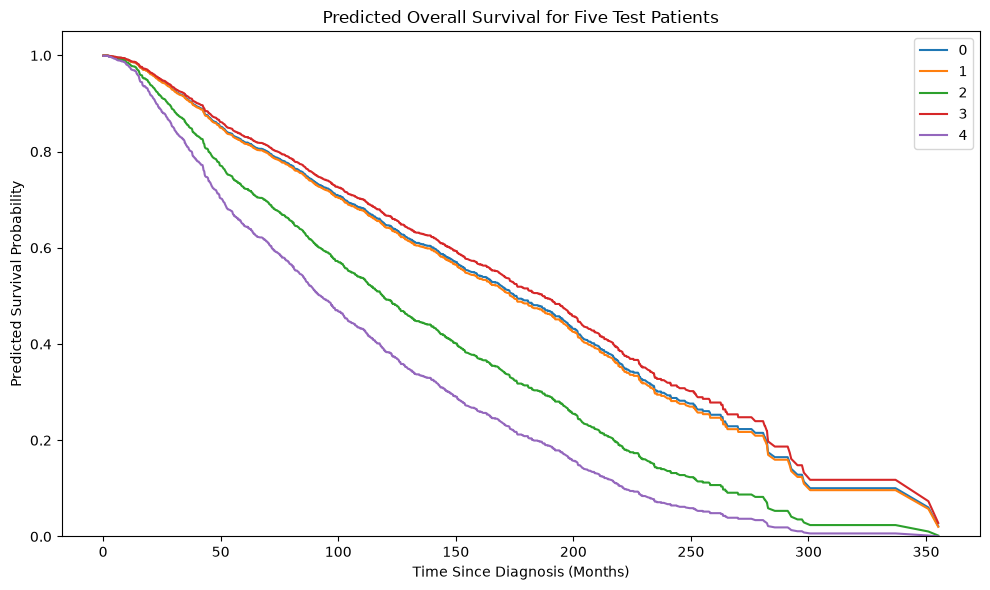

In [19]:

selected_patients = X_test.iloc[:5]

survival_curves = (
    cox_predictive_model.predict_survival_function(
        selected_patients
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

survival_curves.plot(
    ax=ax,
    legend=True
)

ax.set_title(
    "Predicted Overall Survival for Five Test Patients"
)

ax.set_xlabel(
    "Time Since Diagnosis (Months)"
)

ax.set_ylabel(
    "Predicted Survival Probability"
)

ax.set_ylim(0, 1.05)

plt.tight_layout()

plt.show()

In [21]:

import joblib

RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

performance_df.to_csv(
    RESULTS_DIR / "cox_predictive_performance.csv",
    index=False
)

survival_predictions_df.to_csv(
    RESULTS_DIR / "cox_test_survival_predictions.csv",
    index=False
)

joblib.dump(
    cox_predictive_model,
    RESULTS_DIR / "cox_predictive_model.joblib"
)

print("Cox prediction results saved successfully!")

Cox prediction results saved successfully!


In [23]:

five_year = survival_predictions_df[
    "Predicted_5_Year_Survival"
]

ten_year = survival_predictions_df[
    "Predicted_10_Year_Survival"
]

assert five_year.between(0, 1).all()

assert ten_year.between(0, 1).all()

assert (ten_year <= five_year).all()

assert len(survival_predictions_df) == len(y_test)

print("All survival prediction checks passed!")

All survival prediction checks passed!


In [25]:

evaluation_time = 60

died_by_five_years = (
    (y_test["EVENT"] == 1)
    & (y_test["OS_MONTHS"] <= evaluation_time)
)

followed_beyond_five_years = (
    y_test["OS_MONTHS"] > evaluation_time
)

censored_before_five_years = (
    (y_test["EVENT"] == 0)
    & (y_test["OS_MONTHS"] <= evaluation_time)
)

print(
    "Deaths by five years:",
    died_by_five_years.sum()
)

print(
    "Observed beyond five years:",
    followed_beyond_five_years.sum()
)

print(
    "Censored by five years:",
    censored_before_five_years.sum()
)

assert (
    died_by_five_years.sum()
    + followed_beyond_five_years.sum()
    + censored_before_five_years.sum()
) == len(y_test)

Deaths by five years: 84
Observed beyond five years: 302
Censored by five years: 11


In [27]:

from lifelines import KaplanMeierFitter

calibration_df = pd.DataFrame({
    "OS_MONTHS": y_test["OS_MONTHS"].to_numpy(),
    "EVENT": y_test["EVENT"].to_numpy(),
    "Predicted_5_Year_Survival": survival_predictions_df[
        "Predicted_5_Year_Survival"
    ].to_numpy()
})

calibration_df["Prediction_Group"] = pd.qcut(
    calibration_df["Predicted_5_Year_Survival"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

calibration_results = []

for group, group_df in calibration_df.groupby(
    "Prediction_Group",
    observed=True
):
    kmf = KaplanMeierFitter()

    kmf.fit(
        durations=group_df["OS_MONTHS"],
        event_observed=group_df["EVENT"]
    )

    observed_survival = kmf.predict(60)

    confidence_interval = kmf.confidence_interval_survival_function_

    lower_ci = np.interp(
        60,
        confidence_interval.index,
        confidence_interval.iloc[:, 0]
    )

    upper_ci = np.interp(
        60,
        confidence_interval.index,
        confidence_interval.iloc[:, 1]
    )

    calibration_results.append({
        "Group": group,
        "Patients": len(group_df),
        "Mean_Predicted_Survival": group_df[
            "Predicted_5_Year_Survival"
        ].mean(),
        "Observed_KM_Survival": observed_survival,
        "Lower_95_CI": lower_ci,
        "Upper_95_CI": upper_ci
    })

calibration_results_df = pd.DataFrame(
    calibration_results
)

display(calibration_results_df.round(4))

,Group,Patients,Mean_Predicted_Survival,Observed_KM_Survival,Lower_95_CI,Upper_95_CI
0,Q1,100,0.6054,0.6359,0.5254,0.7153
1,Q2,99,0.7707,0.7876,0.6931,0.8560
2,Q3,99,0.8367,0.8426,0.7448,0.8966
3,Q4,99,0.9004,0.8783,0.7957,0.9290


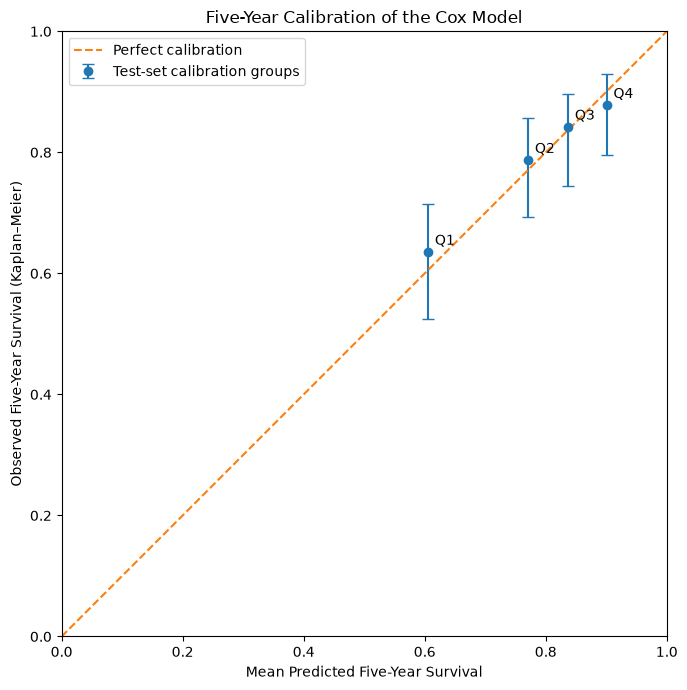

In [29]:

fig, ax = plt.subplots(figsize=(7, 7))

ax.errorbar(
    calibration_results_df["Mean_Predicted_Survival"],
    calibration_results_df["Observed_KM_Survival"],
    yerr=[
        calibration_results_df["Observed_KM_Survival"]
        - calibration_results_df["Lower_95_CI"],
        calibration_results_df["Upper_95_CI"]
        - calibration_results_df["Observed_KM_Survival"]
    ],
    fmt="o",
    capsize=4,
    label="Test-set calibration groups"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

for _, row in calibration_results_df.iterrows():
    ax.annotate(
        row["Group"],
        (
            row["Mean_Predicted_Survival"],
            row["Observed_KM_Survival"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Mean Predicted Five-Year Survival")

ax.set_ylabel("Observed Five-Year Survival (Kaplan–Meier)")

ax.set_title("Five-Year Calibration of the Cox Model")

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

ax.set_aspect("equal", adjustable="box")

ax.legend()

plt.tight_layout()

plt.show()

In [31]:

from lifelines import KaplanMeierFitter

censoring_km = KaplanMeierFitter()

censoring_km.fit(
    durations=y_train["OS_MONTHS"],
    event_observed=1 - y_train["EVENT"]
)

print(
    "Estimated probability of remaining uncensored at 60 months:",
    round(float(censoring_km.predict(60)), 4)
)

Estimated probability of remaining uncensored at 60 months: 0.9635


In [33]:

evaluation_time = 60

test_times = y_test["OS_MONTHS"].to_numpy()

test_events = y_test["EVENT"].to_numpy()

predicted_survival = survival_predictions_df[
    "Predicted_5_Year_Survival"
].to_numpy()

event_by_time = (
    (test_times <= evaluation_time)
    & (test_events == 1)
)

observed_beyond_time = (
    test_times > evaluation_time
)

censoring_survival_at_events = (
    censoring_km.predict(
        test_times[event_by_time] - 1e-8
    ).to_numpy()
)

censoring_survival_at_time = float(
    censoring_km.predict(evaluation_time)
)

print(
    "Minimum censoring survival at event times:",
    censoring_survival_at_events.min()
)

print(
    "Censoring survival at 60 months:",
    censoring_survival_at_time
)

assert (censoring_survival_at_events > 0).all()

assert censoring_survival_at_time > 0

brier_contributions = np.zeros(len(y_test))

brier_contributions[event_by_time] = (
    predicted_survival[event_by_time] ** 2
    / censoring_survival_at_events
)

brier_contributions[observed_beyond_time] = (
    (1 - predicted_survival[observed_beyond_time]) ** 2
    / censoring_survival_at_time
)

brier_score_60 = brier_contributions.mean()

print(
    "Five-year IPCW Brier score:",
    round(brier_score_60, 4)
)

Minimum censoring survival at event times: 0.9667627372281264
Censoring survival at 60 months: 0.9635448214723275
Five-year IPCW Brier score: 0.157


In [35]:

from lifelines import KaplanMeierFitter

baseline_km = KaplanMeierFitter()

baseline_km.fit(
    durations=y_train["OS_MONTHS"],
    event_observed=y_train["EVENT"]
)

baseline_survival_60 = float(
    baseline_km.predict(60)
)

print(
    "Training-cohort five-year survival:",
    round(baseline_survival_60, 4)
)

Training-cohort five-year survival: 0.7789


In [37]:

baseline_predictions = np.full(
    len(y_test),
    baseline_survival_60
)

baseline_contributions = np.zeros(
    len(y_test)
)

baseline_contributions[event_by_time] = (
    baseline_predictions[event_by_time] ** 2
    / censoring_survival_at_events
)

baseline_contributions[observed_beyond_time] = (
    (1 - baseline_predictions[observed_beyond_time]) ** 2
    / censoring_survival_at_time
)

baseline_brier_60 = baseline_contributions.mean()

print(
    "Baseline five-year IPCW Brier score:",
    round(baseline_brier_60, 4)
)

Baseline five-year IPCW Brier score: 0.1698


In [39]:

brier_comparison = pd.DataFrame({
    "Model": [
        "Kaplan-Meier baseline",
        "Cox clinical model"
    ],
    "Five_Year_IPCW_Brier": [
        baseline_brier_60,
        brier_score_60
    ]
})

display(
    brier_comparison.round(4)
)

absolute_improvement = (
    baseline_brier_60 - brier_score_60
)

relative_improvement = (
    absolute_improvement / baseline_brier_60
) * 100

print(
    "Absolute Brier score improvement:",
    round(absolute_improvement, 4)
)

print(
    "Relative Brier score improvement (%):",
    round(relative_improvement, 2)
)

,Model,Five_Year_IPCW_Brier
0,Kaplan-Meier baseline,0.1698
1,Cox clinical model,0.1570


Absolute Brier score improvement: 0.0128
Relative Brier score improvement (%): 7.55


In [41]:

brier_comparison.to_csv(
    RESULTS_DIR / "cox_five_year_brier_comparison.csv",
    index=False
)

calibration_results_df.to_csv(
    RESULTS_DIR / "cox_five_year_calibration.csv",
    index=False
)

print("Five-year evaluation results saved successfully!")

Five-year evaluation results saved successfully!
